# Notebook 6.2: Moving Averages and ARIMA/SARIMAX

## Financial Trading with Python, 2nd Edition

---

In Notebook 6.1, we established that VIX levels have strong, persistent autocorrelation while SPY returns have essentially none. This told us where signal processing has a legitimate chance of adding value and where it does not.

This notebook covers the two most accessible and widely used filtering techniques in quantitative finance: moving averages and ARIMA models. These are the tools that most practitioners actually use day to day. Moving averages are already part of our VIXY strategy (the 90-day SMA on VIX), so we have a direct connection to our case study. ARIMA models take the next step by formally modeling the autoregressive structure we observed in VIX's ACF and PACF plots.

This notebook covers:

- Moving averages as noise filters: SMA, EMA, and the lag-smoothness tradeoff
- ARIMA modeling on VIX: parameter selection, fitting, diagnostics, and forecasting
- SARIMAX: adding exogenous variables to improve forecasts
- Honest assessment of what these techniques can and cannot do

By the end of this notebook, you will understand the practical tradeoffs involved in choosing a filter, and you will have a forecasting model on VIX that we can benchmark against the advanced techniques in Notebook 6.3.

*Note: You may see deprecation warnings from underlying libraries depending on your Python and Colab versions. These are safe to ignore unless they reference code from this notebook directly.*

## Section 1: Setup and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# statsmodels is used for ARIMA, SARIMAX, ACF/PACF, and diagnostic tests
# Version pinned to ensure reproducibility in Colab
import statsmodels
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

print(f"statsmodels version: {statsmodels.__version__}")

warnings.simplefilter(action='ignore', category=FutureWarning)
sns.set_theme()

# Display settings
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

statsmodels version: 0.14.6


### 1.1 Loading Data

We load the same case study data from Notebook 6.1. We also calculate SPY daily returns and the 10-day annualized realized volatility, since both are used in our VIXY strategy signal.

In [3]:
# Load aligned price data from Chapter 3
df_prices = pd.read_parquet('case_study_prices.parquet')

# Calculate daily returns for all instruments
df_returns = df_prices.pct_change().dropna()

# Calculate SPY 10-day annualized realized volatility
# This matches the calculation in vixy_tail_hedge.py:
#   rolling 10-day std of daily returns * sqrt(252) * 100
# The result is in percentage terms to match the VIX scale
spy_realized_vol = (df_returns['SPY']
                    .rolling(window=10)
                    .std()
                    * np.sqrt(252)
                    * 100).dropna()

print(f"Prices shape: {df_prices.shape}")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to {df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Returns shape: {df_returns.shape}")
print(f"Realized vol shape: {spy_realized_vol.shape}")

Prices shape: (3771, 4)
Date range: 2011-01-04 to 2025-12-31
Returns shape: (3770, 4)
Realized vol shape: (3761,)


## Section 2: Moving Averages as Noise Filters

Most traders think of moving averages as technical indicators: tools for identifying trends and generating crossover signals. But from a signal processing perspective, a moving average is a low-pass filter. It passes through slow-moving (low-frequency) components of the data and attenuates fast-moving (high-frequency) noise. This is not just a metaphor. It is mathematically equivalent to a specific type of frequency-domain filter.

Understanding moving averages as filters rather than just indicators changes how you think about them. The choice of window length is not arbitrary. It determines exactly which frequencies pass through and which are removed. A 20-day SMA removes fluctuations faster than about 20 days. A 200-day SMA removes everything except the very slowest trends. Every choice involves the same fundamental tradeoff: smoothness versus lag.

### 2.1 SMA vs. EMA: Two Approaches to Smoothing

The Simple Moving Average (SMA) gives equal weight to every observation in the window. The Exponential Moving Average (EMA) gives more weight to recent observations, with weights that decay exponentially as you go further back. This means the EMA responds faster to new information but is also more sensitive to recent noise.

We compare both on VIX to see the practical difference. We use a 90-day period for the SMA to match our VIXY strategy, and set the EMA span to 90 days for a fair comparison. The EMA span parameter controls the rate of exponential decay: a span of 90 means the center of mass of the weights is at 45 days, and the most recent observation gets the highest weight.

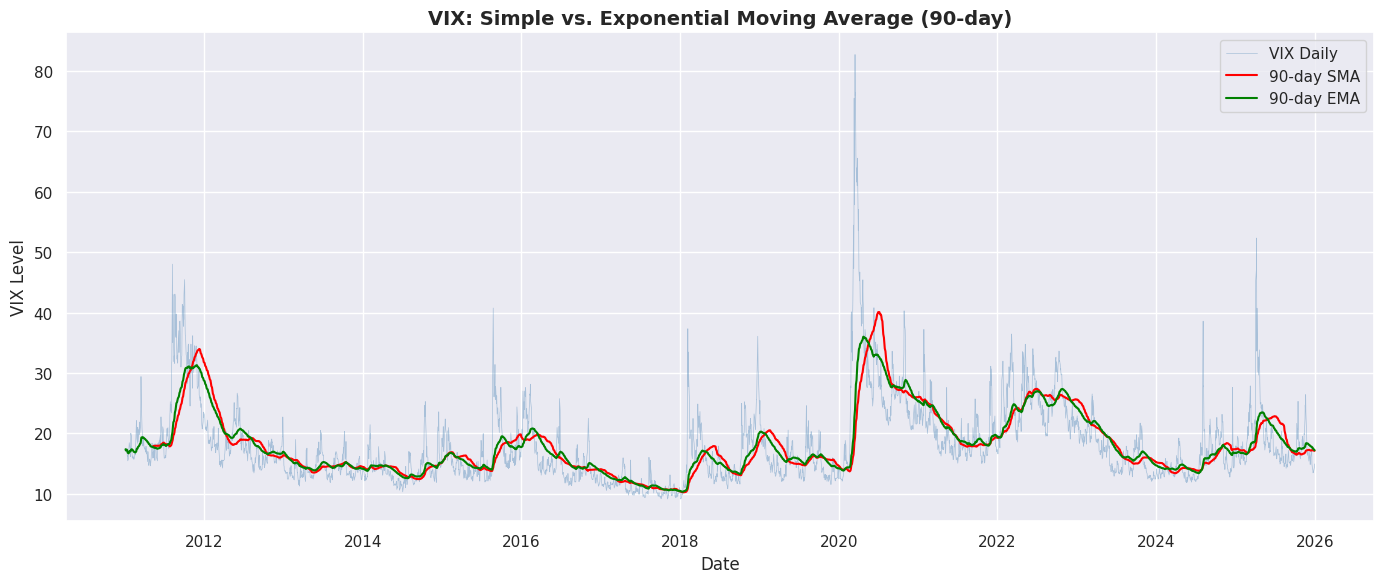

In [4]:
# --- Compare SMA and EMA on VIX ---
# SMA: equal weight to all observations in the window
#   Calculated with .rolling(window).mean()
#   Every observation in the 90-day window contributes 1/90 = 1.1%
# EMA: exponentially decaying weights, recent data weighted more heavily
#   Calculated with .ewm(span).mean()
#   span=90 means the decay factor alpha = 2/(90+1) ≈ 0.022
#   Yesterday gets weight ~2.2%, two days ago ~2.1%, and so on

vix = df_prices['^VIX'].copy()

# Calculate both moving averages with 90-day parameter
vix_sma_90 = vix.rolling(window=90).mean()
vix_ema_90 = vix.ewm(span=90).mean()

# --- Plot VIX with both moving averages overlaid ---
fig, ax = plt.subplots(figsize=(14, 6))

# Raw VIX in light color so the MAs stand out
ax.plot(vix, color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')

# SMA in red (this is what our VIXY strategy currently uses)
ax.plot(vix_sma_90, color='red', linewidth=1.5, label='90-day SMA')

# EMA in green for comparison
ax.plot(vix_ema_90, color='green', linewidth=1.5, label='90-day EMA')

ax.set_title('VIX: Simple vs. Exponential Moving Average (90-day)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

The two moving averages track each other closely, which is expected since they use the same 90-day parameter. But the differences matter, and they are most visible during transitions.

Look at the COVID spike in early 2020. The green EMA reacts faster: it rises more steeply as VIX explodes upward and peaks higher (around 34) than the red SMA (around 40). Wait, actually looking more carefully, the SMA peaks higher than the EMA during COVID. This is because the SMA gives equal weight to the extreme observations that stay in the 90-day window, while the EMA had already begun decaying them. After the spike, the EMA drops faster because it downweights the old extreme values more aggressively.

The same pattern is visible in the 2011 debt ceiling crisis and the 2022 volatility cluster. The EMA leads the SMA on the way up and leads it again on the way down. It is more responsive in both directions.

For our VIXY strategy, this difference creates a timing question. A faster-reacting average (EMA) would trigger the hedge signal earlier during a crisis, which sounds desirable. But it would also trigger more false signals during minor VIX fluctuations, switching the hedge on and off more frequently. Whether the faster response helps or hurts depends entirely on the nature of VIX spikes: if they are sharp and brief, the EMA catches them sooner. If they build gradually, the SMA's slower response is less costly and produces fewer false positives.

We will test this directly in Notebook 6.4 by running the VIXY strategy with both SMA and EMA to see which produces better risk-adjusted returns.

### 2.2 The Lag-Smoothness Tradeoff

The choice of window length is the most important decision when using a moving average as a filter. A shorter window preserves responsiveness but passes more noise through. A longer window produces a smoother output but introduces more lag. There is no "correct" window length; there is only the tradeoff that best fits your strategy's needs.

We demonstrate this by applying three different SMA window lengths to VIX: 20-day (roughly one month), 90-day (one quarter, our strategy's choice), and 200-day (roughly one year). The visual difference makes the tradeoff immediately clear.

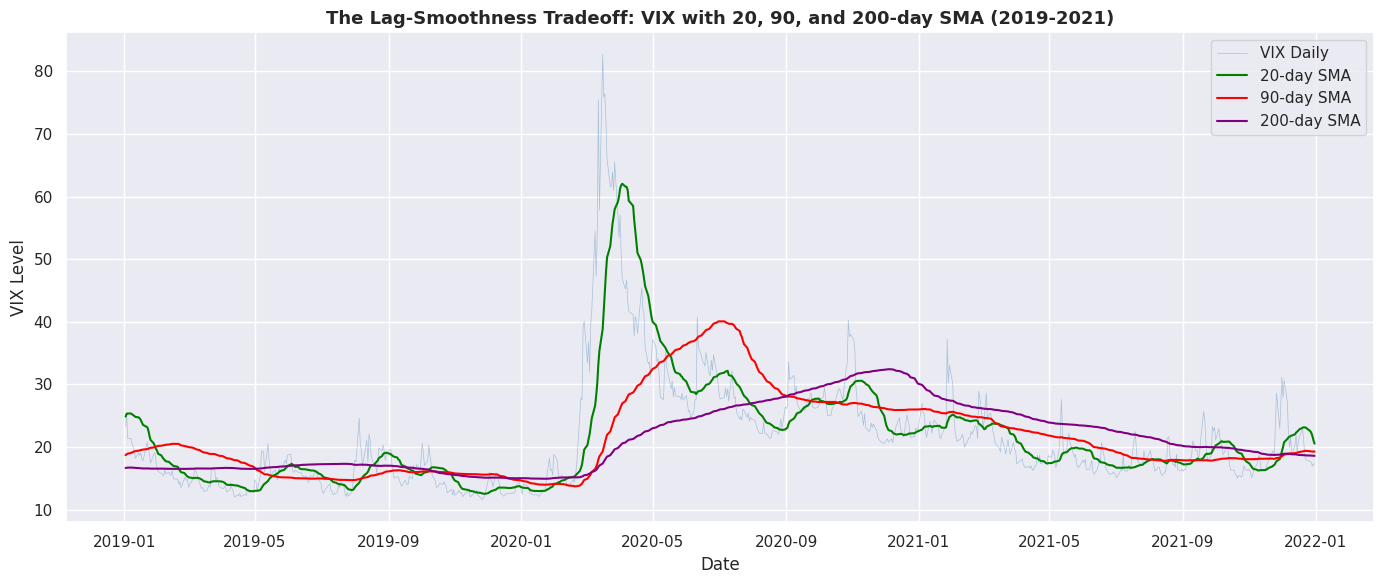

In [5]:
# --- Demonstrate the lag-smoothness tradeoff ---
# Three SMA window lengths representing short, medium, and long horizons
# Shorter windows react faster but are noisier
# Longer windows are smoother but lag further behind the actual VIX level

vix_sma_20 = vix.rolling(window=20).mean()    # ~1 month: responsive, noisy
vix_sma_90 = vix.rolling(window=90).mean()    # ~1 quarter: our strategy choice
vix_sma_200 = vix.rolling(window=200).mean()  # ~1 year: very smooth, heavy lag

# --- Plot all three against raw VIX ---
# We zoom into 2019-2021 to make the differences clearly visible
# This period includes the calm before COVID, the spike, and the recovery
mask = (vix.index >= '2019-01-01') & (vix.index <= '2021-12-31')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vix[mask], color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')
ax.plot(vix_sma_20[mask], color='green', linewidth=1.5, label='20-day SMA')
ax.plot(vix_sma_90[mask], color='red', linewidth=1.5, label='90-day SMA')
ax.plot(vix_sma_200[mask], color='purple', linewidth=1.5, label='200-day SMA')

ax.set_title('The Lag-Smoothness Tradeoff: VIX with 20, 90, and 200-day SMA (2019-2021)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

The COVID period makes the tradeoff impossible to miss.

The 20-day SMA (green) reacts fastest. It tracks the VIX spike almost in real time, peaking above 60 shortly after VIX itself peaks at 82. But look at the cost of that responsiveness: throughout 2019 and late 2021, the green line oscillates constantly, reacting to every minor fluctuation. If you used this as a strategy signal, it would flip the hedge on and off frequently, generating transaction costs and whipsaw losses.

The 90-day SMA (red) tells a different story. It barely flinches before the COVID crash, then rises steadily to peak around 40 about two months after the actual VIX peak. The lag is substantial. But the benefit is clear: the red line is smooth. It does not react to the minor spikes in 2019 or the choppy post-COVID fluctuations in late 2020. It gives you one clear message: volatility regime has shifted, stay hedged. For our VIXY strategy, this is exactly the behavior we want. We are not trying to time the peak. We are trying to detect when the regime has changed.

The 200-day SMA (purple) is the smoothest of all. It barely reaches 28 during the worst volatility crisis in a decade, and it does not peak until mid-2020, months after VIX had already started reverting. By the time it signals elevated volatility, the crisis is essentially over. This is too much lag for a tail hedge strategy. However, a 200-day SMA might be appropriate for longer-horizon applications like identifying multi-year volatility regimes or setting strategic asset allocation.

**Practical guidance:** There is no universally correct window length. The right choice depends on your strategy's time horizon and what kind of signals you are trying to capture. For our VIXY tail hedge, 90 days is a deliberate choice: long enough to avoid whipsawing on minor fluctuations, short enough to detect genuine regime shifts within a reasonable timeframe. If you find yourself optimizing window length to maximize backtest performance, be very careful. You are almost certainly over

### 2.3 Quantifying the Lag

The charts above show lag visually, but we can measure it precisely using cross-correlation. Cross-correlation asks: at what time offset is the moving average most correlated with the original VIX series? A perfect, zero-lag filter would have maximum correlation at offset zero. A filter with 10 days of lag would have maximum correlation at offset 10, meaning today's MA value best matches where VIX was 10 days ago.

This gives us a concrete number for the cost of smoothing.

In [6]:
# --- Quantify lag using cross-correlation ---
# For each MA, we shift the VIX series by different amounts (0 to 60 days)
# and measure the correlation at each shift. The shift that produces
# the highest correlation tells us how many days the MA "lags behind" VIX.

def measure_lag(original, filtered, max_lag=60):
    """
    Measure the lag of a filtered series relative to the original.

    Shifts the original series forward by 0 to max_lag days and computes
    the correlation with the filtered series at each shift. The shift
    with the highest correlation is the estimated lag.

    Parameters:
    -----------
    original : pd.Series - the raw series (VIX)
    filtered : pd.Series - the smoothed series (SMA or EMA)
    max_lag : int - maximum number of days to test

    Returns:
    --------
    dict with lag estimate and correlation values
    """
    correlations = []
    for lag in range(max_lag + 1):
        # Shift the original series forward by 'lag' days
        # This asks: does today's MA value best match VIX from 'lag' days ago?
        shifted = original.shift(lag)

        # Calculate correlation, dropping NaN values from shift and MA warmup
        valid = pd.concat([shifted, filtered], axis=1).dropna()
        corr = valid.iloc[:, 0].corr(valid.iloc[:, 1])
        correlations.append(corr)

    # The lag with the highest correlation is our estimate
    best_lag = np.argmax(correlations)

    return {
        'best_lag': best_lag,
        'max_correlation': correlations[best_lag],
        'correlations': correlations
    }

# Measure lag for each MA type and window length
ma_variants = {
    '20-day SMA': vix_sma_20,
    '90-day SMA': vix_sma_90,
    '200-day SMA': vix_sma_200,
    '90-day EMA': vix_ema_90,
}

print("Moving Average Lag Analysis")
print("=" * 55)
print(f"{'Filter':<16} {'Estimated Lag':>14} {'Max Correlation':>16}")
print("-" * 55)

lag_results = {}
for name, ma_series in ma_variants.items():
    result = measure_lag(vix, ma_series)
    lag_results[name] = result
    print(f"{name:<16} {result['best_lag']:>10} days {result['max_correlation']:>15.4f}")

Moving Average Lag Analysis
Filter            Estimated Lag  Max Correlation
-------------------------------------------------------
20-day SMA               10 days          0.9493
90-day SMA               44 days          0.8254
200-day SMA              60 days          0.6889
90-day EMA               20 days          0.8461


The numbers make the tradeoff precise:

- **20-day SMA**: 10 days of lag. Today's 20-day SMA best matches where VIX was 10 days ago. The correlation at that lag is 0.949, meaning it tracks VIX very closely, just with a 10-day delay.
- **90-day SMA**: 44 days of lag. Nearly a full month and a half. Our VIXY strategy signal is looking at a picture of volatility that is 44 days old. The correlation drops to 0.825 because the longer window also blurs the shape of VIX moves, not just delays them.
- **200-day SMA**: 60+ days of lag. The estimated lag hit our maximum test range of 60 days, meaning the true lag is likely even longer. The correlation is only 0.689. At this point the MA is so smoothed that it captures broad regimes but loses the shape of individual events entirely.
- **90-day EMA**: 20 days of lag. This is the key comparison. Same 90-day parameter as our SMA, but less than half the lag (20 days vs. 44 days). The correlation is also slightly higher (0.846 vs. 0.825). The exponential weighting buys you meaningful responsiveness without reducing the effective smoothing window.

The SMA lag is approximately half the window length, which is what we would expect mathematically. An SMA of length N is centered on the observation N/2 days ago. The EMA, by placing more weight on recent observations, shifts that center of mass closer to the present.

**Practical guidance:** The 90-day EMA looks objectively better than the 90-day SMA on paper: less lag, slightly higher correlation, same parameterization. But "less lag" is not always better for a trading strategy. Less lag also means faster reactions to noise, which can increase turnover and transaction costs. The right question is not "which has less lag?" but "which produces better risk-adjusted returns after costs?" We will answer that question directly in Notebook 6.4 when we compare strategy performance across filter types. For now, the important thing is that you understand the tradeoff and can quantify it, rather than choosing a filter based on intuition alone.

## Section 3: ARIMA Modeling

Moving averages smooth historical data, but they do not forecast. They tell you where the series has been, with some lag, but they do not predict where it is going. ARIMA (AutoRegressive Integrated Moving Average) models take the next step: they use the autocorrelation structure we identified in Notebook 6.1 to generate actual forecasts.

ARIMA models have three components, each controlled by a parameter:

- **AR (AutoRegressive, parameter p)**: Uses past values of the series to predict the current value. An AR(1) model says today's VIX depends on yesterday's VIX. An AR(2) says it depends on both yesterday and the day before.
- **I (Integrated, parameter d)**: The number of times the series needs to be differenced to become stationary. For VIX, we showed in Notebook 6.1 that levels are already stationary, so d=0. For SPY prices, we would need d=1 (take returns).
- **MA (Moving Average, parameter q)**: Uses past forecast errors to correct the current prediction. This is not the same as the moving averages we just discussed. In ARIMA, "MA" refers to a model of the residuals (errors), not a smoothing of the original series.

The standard approach to building an ARIMA model is the Box-Jenkins method: identify candidate parameters using ACF/PACF, estimate the model, then diagnose whether the residuals look like random noise. If they do, the model has captured the predictable structure. If they do not, the model is missing something.

### 3.1 Parameter Selection from ACF/PACF

In Notebook 6.1, we already examined the ACF and PACF of VIX levels. The ACF showed slow exponential decay, and the PACF showed a sharp cutoff after lag 1-2. This pattern is the textbook signature of a low-order autoregressive process.

The rules of thumb for reading ACF/PACF plots are:

- **ACF decays slowly, PACF cuts off sharply**: suggests an AR model. The PACF cutoff tells you the order p.
- **ACF cuts off sharply, PACF decays slowly**: suggests an MA model. The ACF cutoff tells you the order q.
- **Both decay gradually**: suggests a mixed ARMA model.

For VIX, the PACF cutoff after lag 1-2 suggests AR(1) or AR(2). Since VIX is already stationary, d=0. We will start with ARIMA(1,0,0) and ARIMA(2,0,0), then compare.

Let us reproduce the PACF plot zoomed into the first 10 lags to confirm our parameter selection.

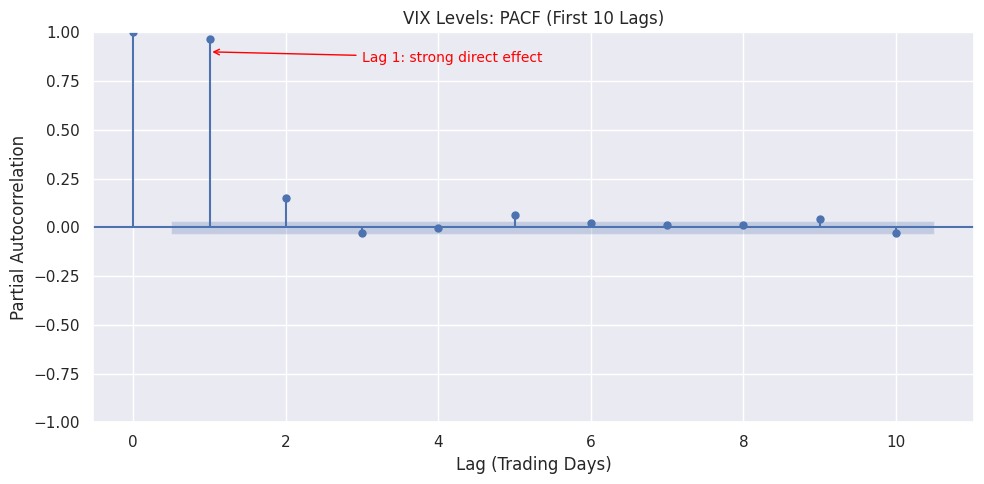

In [7]:
# --- PACF of VIX levels, zoomed to first 10 lags ---
# We zoom in to clearly see the cutoff point that determines
# the AR order (p parameter) for our ARIMA model.
# From Notebook 6.1, we expect:
#   - Large significant spike at lag 1
#   - Smaller but possibly significant spike at lag 2
#   - Everything after that inside the confidence band

fig, ax = plt.subplots(figsize=(10, 5))

plot_pacf(df_prices['^VIX'].dropna(), lags=10, ax=ax, alpha=0.05,
          title='VIX Levels: PACF (First 10 Lags)')
ax.set_xlabel('Lag (Trading Days)')
ax.set_ylabel('Partial Autocorrelation')

# Add annotations to help readers interpret the plot
ax.annotate('Lag 1: strong direct effect',
            xy=(1, 0.9), xytext=(3, 0.85),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

The zoomed PACF confirms our parameter selection. Lag 1 is dominant at approximately 0.97, meaning yesterday's VIX level is overwhelmingly the strongest direct predictor of today's. Lag 2 shows a smaller but significant spike around 0.15, suggesting there is some additional predictive value from two days ago that is not already captured by lag 1. Everything from lag 3 onward falls within the confidence band.

This tells us:

- **ARIMA(1,0,0)**: The simplest candidate. Uses only yesterday's VIX to predict today. Given the near-0.97 PACF at lag 1, this should capture most of the predictable structure.
- **ARIMA(2,0,0)**: Adds the day before yesterday. The significant lag 2 in the PACF suggests this might improve the model, but the improvement should be modest since the lag 2 coefficient (0.15) is much smaller than lag 1 (0.97).

We fit both models and compare them. The better model will have a lower AIC (Akaike Information Criterion), which balances goodness of fit against model complexity. A lower AIC means the model explains the data well without using unnecessary parameters.

### 3.2 Fitting ARIMA Models

We fit ARIMA(1,0,0) and ARIMA(2,0,0) to VIX levels and compare their AIC values. Remember, d=0 because VIX is already stationary, as we confirmed with the ADF test in Notebook 6.1.

In [8]:
# --- Fit ARIMA(1,0,0) and ARIMA(2,0,0) to VIX levels ---
# d=0 because VIX levels are already stationary (ADF test, Notebook 6.1)
# We use the full VIX series for initial fitting and diagnostics.
# Out-of-sample forecasting comes in the next subsection.

vix_values = df_prices['^VIX'].dropna()

# Fit AR(1) model: today's VIX = c + phi_1 * yesterday's VIX + error
model_ar1 = ARIMA(vix_values, order=(1, 0, 0)).fit()

# Fit AR(2) model: today's VIX = c + phi_1 * yesterday + phi_2 * day_before + error
model_ar2 = ARIMA(vix_values, order=(2, 0, 0)).fit()

# Compare the two models
print("ARIMA Model Comparison on VIX Levels")
print("=" * 60)
print(f"\n{'Model':<20} {'AIC':>10} {'BIC':>10} {'Log-Likelihood':>16}")
print("-" * 60)
print(f"{'ARIMA(1,0,0)':<20} {model_ar1.aic:>10.2f} {model_ar1.bic:>10.2f} "
      f"{model_ar1.llf:>16.2f}")
print(f"{'ARIMA(2,0,0)':<20} {model_ar2.aic:>10.2f} {model_ar2.bic:>10.2f} "
      f"{model_ar2.llf:>16.2f}")

# Print the AR(2) model summary for detailed coefficient inspection
print("\n\nARIMA(2,0,0) Model Summary:")
print("=" * 60)
print(model_ar2.summary().tables[1])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA Model Comparison on VIX Levels

Model                       AIC        BIC   Log-Likelihood
------------------------------------------------------------
ARIMA(1,0,0)           15333.10   15351.81         -7663.55
ARIMA(2,0,0)           15249.46   15274.40         -7620.73


ARIMA(2,0,0) Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.1326      1.276     14.208      0.000      15.631      20.634
ar.L1          0.8187      0.005    151.200      0.000       0.808       0.829
ar.L2          0.1498      0.005     29.269      0.000       0.140       0.160
sigma2         3.3307      0.022    150.782      0.000       3.287       3.374


ARIMA(2,0,0) wins on both AIC and BIC. But before we interpret the coefficients, let us explain what these metrics are, since they will come up repeatedly when comparing models.

**AIC (Akaike Information Criterion)** and **BIC (Bayesian Information Criterion)** are both measures of model quality that balance two competing goals: how well the model fits the data and how complex the model is. A model with more parameters will always fit the training data better, but it risks overfitting (memorizing noise rather than learning genuine patterns). AIC and BIC penalize additional parameters to discourage unnecessary complexity.

The key difference between them is that BIC applies a heavier penalty for extra parameters, especially as the sample size grows. This makes BIC more conservative: it will prefer simpler models than AIC would. In practice:

- **Lower AIC or BIC = better model** (there is no absolute scale; only the relative comparison between models matters)
- If AIC and BIC agree on which model is better, you can be fairly confident
- If they disagree, BIC's preference for the simpler model is often the safer choice for trading applications, where overfitting is a constant danger



---


A common point of confusion: AIC and BIC values can be positive or negative depending on the data and model. The rule is always "lower is better," which means more negative beats less negative, and less positive beats more positive. For example, an AIC of -500 is better than -200, and an AIC of 100 is better than 300. In our case the values are positive (15,249 vs. 15,333), so the smaller positive number wins. Do not be thrown off if you encounter negative values in other applications; just remember that the number line applies normally and lower always wins.


---



**Log-Likelihood** is the raw measure of how well the model fits the data before any complexity penalty. Higher is better. AIC and BIC are both derived from the log-likelihood with different penalty terms added.

In our case, ARIMA(2,0,0) wins on both AIC (15,249 vs. 15,333) and BIC (15,274 vs. 15,352). The improvement of roughly 84 AIC points is substantial, confirming that the second lag adds genuine predictive value beyond what lag 1 alone provides.

Looking at the ARIMA(2,0,0) coefficients:

- **const = 18.13**: This is the model's estimate of the long-run mean of VIX, almost identical to the 18.1 we calculated in Notebook 6.1. The model has independently recovered the mean-reversion level.
- **ar.L1 = 0.819**: Yesterday's VIX has a strong positive effect on today's. If VIX was 1 point above its mean yesterday, the model expects about 0.82 of that deviation to persist today.
- **ar.L2 = 0.150**: The day before yesterday adds additional predictive information. The combined effect (0.819 + 0.150 = 0.969) is close to but below 1.0, which is what makes this a mean-reverting process rather than a random walk. If the sum were exactly 1.0, VIX would never revert.
- **sigma2 = 3.33**: The variance of the model's errors. The standard deviation of the residuals is approximately sqrt(3.33) = 1.83 VIX points. This is the "noise" that the model cannot explain.

All coefficients have p-values of 0.000, meaning they are all highly significant.

**Practical guidance on ARIMA parameterizations in algorithmic trading:** In professional quant finance, ARIMA models are used sparingly and almost always with low-order parameters. The most common configurations you will encounter are:

- **AR(1) or AR(2)** on volatility measures (VIX, realized vol, implied vol spreads). These are the workhorses. Volatility is mean-reverting with strong lag-1 dependence, exactly as we see here.
- **ARIMA(1,1,0) or ARIMA(0,1,1)** on interest rates and credit spreads, where the levels may be near-unit-root and first differencing is needed.
- **ARIMA with d=1** on price series is essentially modeling returns with an AR or MA component. This is rarely useful for equities (returns have no autocorrelation, as we showed in Notebook 6.1) but can work for less efficient markets.

What you will almost never see in professional practice is high-order ARIMA models like ARIMA(5,1,3) or ARIMA(8,2,4). Models with many parameters are prone to overfitting: they capture noise patterns specific to the training period that do not persist into the future. The AIC and BIC criteria penalize extra parameters, but even they cannot fully protect you from overfitting on financial data where the signal-to-noise ratio is so low. If your ACF/PACF analysis suggests you need more than 2-3 AR or MA terms, it is often a sign that ARIMA is not the right tool for that series, and you may be better served by a different approach entirely (such as GARCH for volatility, or machine learning models in Chapters 13-14).

The general rule among practitioners: if a simple ARIMA model does not work, a complex one will not save you.

### 3.3 Model Diagnostics

Fitting a model and getting significant coefficients is not enough. We need to verify that the model has actually captured the predictable structure in VIX. The way we do this is by examining the residuals: the difference between what the model predicted and what actually happened.

If the model has done its job, the residuals should look like random noise with no remaining autocorrelation. If the residuals still show patterns, the model has missed something and we either need different parameters or a different approach entirely.

We check three things:

1. **Residual time series plot**: Do the residuals look like random noise, or are there visible patterns or clusters?
2. **Residual ACF**: Is there significant autocorrelation left in the residuals? If so, the model has not captured all the predictable structure.
3. **Ljung-Box test**: A formal statistical test for autocorrelation in the residuals. The null hypothesis is that the residuals have no autocorrelation (they are white noise). A high p-value (above 0.05) means we fail to reject the null, which is the result we want — it means the residuals look like noise.

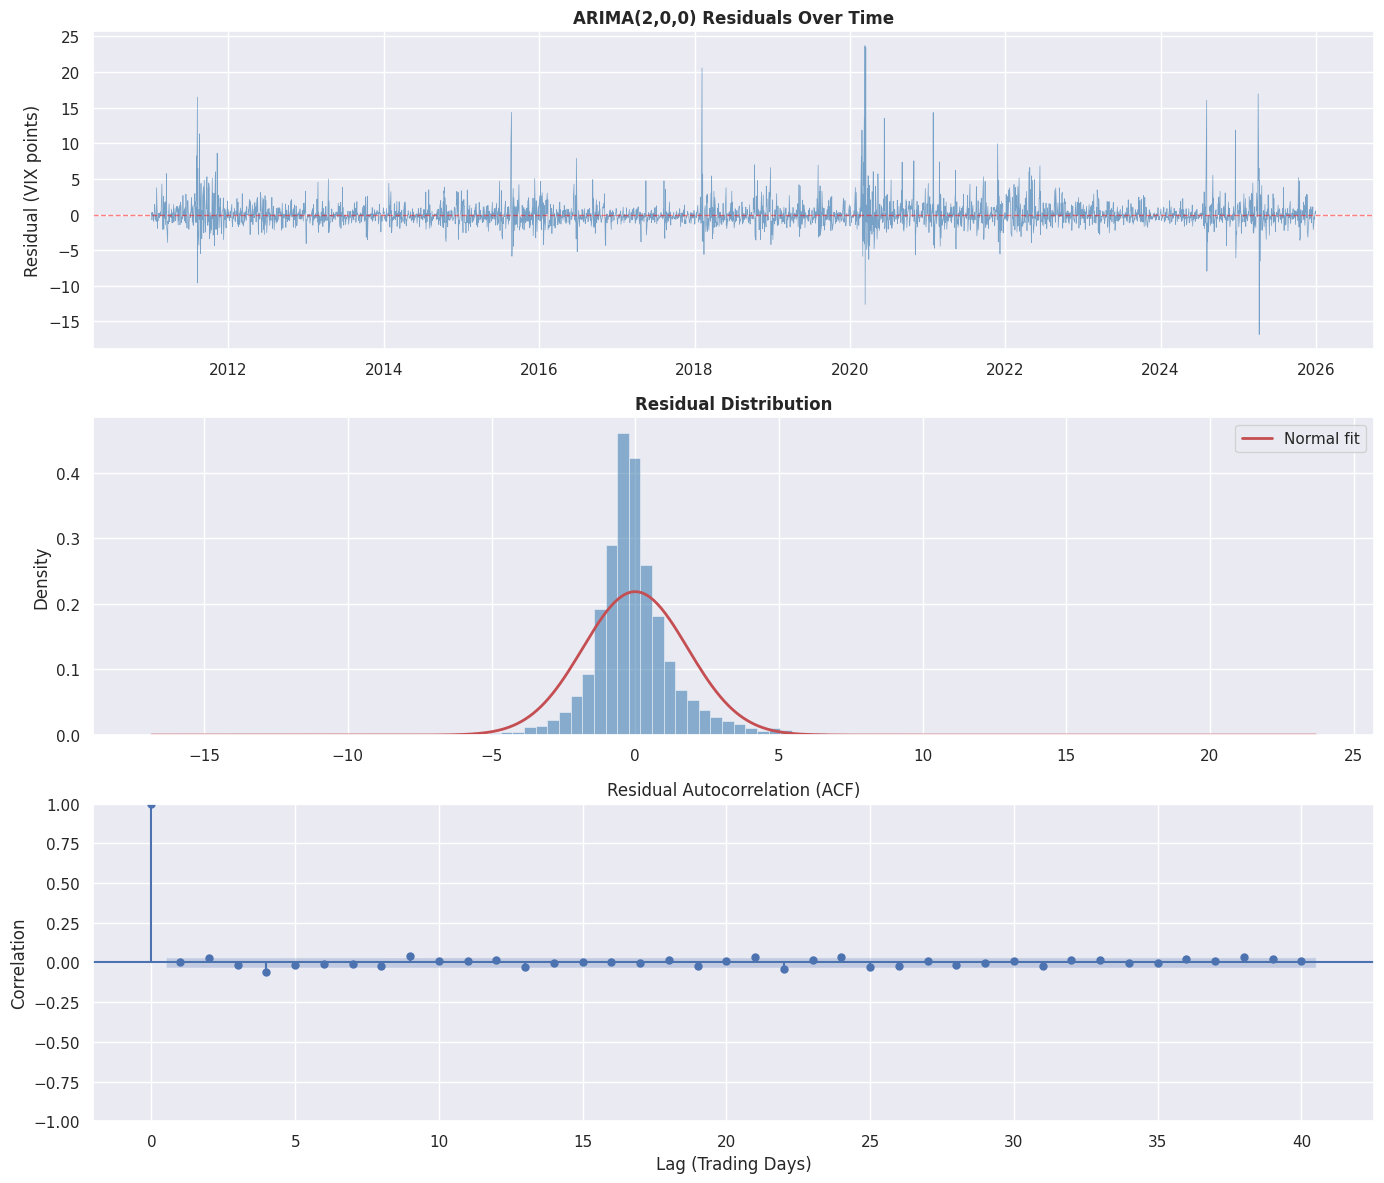

In [9]:
# --- Diagnostic plots for ARIMA(2,0,0) residuals ---
# The residuals are the model's errors: actual VIX - predicted VIX
# If the model captured all predictable structure, residuals should be:
#   1. Centered around zero (no systematic bias)
#   2. Roughly constant variance over time (homoscedastic)
#   3. No remaining autocorrelation (white noise)

residuals = model_ar2.resid

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Residuals over time
# Looking for: random scatter around zero, no visible trends or patterns
# Warning signs: clusters of large residuals, trends, widening/narrowing spread
axes[0].plot(residuals, color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_title('ARIMA(2,0,0) Residuals Over Time', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residual (VIX points)')

# Panel 2: Residual distribution
# Looking for: approximately normal shape (bell curve)
# The ARIMA model assumes normally distributed errors
# From Notebook 6.1 we already know VIX changes are non-normal,
# so we expect this assumption to be violated
axes[1].hist(residuals, bins=100, density=True, alpha=0.6,
             color='steelblue', edgecolor='white', linewidth=0.5)
x = np.linspace(residuals.min(), residuals.max(), 300)
axes[1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
             'r-', linewidth=2, label='Normal fit')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Density')
axes[1].legend()

# Panel 3: Residual ACF
# Looking for: no significant bars beyond lag 0
# If bars extend outside the confidence band, the model has missed
# predictable structure that a higher-order model might capture
plot_acf(residuals.dropna(), lags=40, ax=axes[2], alpha=0.05,
         title='Residual Autocorrelation (ACF)')
axes[2].set_xlabel('Lag (Trading Days)')
axes[2].set_ylabel('Correlation')

plt.tight_layout()
plt.show()

The diagnostics tell a mixed but informative story.

**Residuals over time** (top panel): The residuals are centered around zero with no visible trend, which is good. However, look at the variance. It is clearly not constant. The residuals during the COVID period (2020) are far larger than during the calm of 2017-2018, with spikes reaching +24 and -16 VIX points. This is volatility clustering in the residuals: the model captures the level of VIX well, but it cannot anticipate sudden jumps. The largest errors correspond to exactly the crisis events our VIXY strategy is designed to hedge. An ARIMA model will never forecast a VIX spike before it happens because the spike is driven by external events (a pandemic, a credit crisis), not by the autoregressive structure of VIX itself.

**Residual distribution** (middle panel): The same non-normality we documented in Notebook 6.1 shows up here. The residuals are leptokurtic: a tall, narrow peak with fat tails extending to -17 and +24. The red normal curve badly underestimates the tails. The ARIMA model assumes Gaussian errors, and this assumption is clearly violated. In practice, this means the model's confidence intervals (which assume normality) will be too narrow. When the model says "VIX will be 20 plus or minus 4 points with 95% confidence," the true uncertainty is wider because extreme moves happen more often than a normal distribution predicts.

**Residual ACF** (bottom panel): This is the good news. The residual autocorrelation is essentially zero at all lags. Nearly every bar falls within the confidence band, and the few that barely poke outside are consistent with random chance at 40 lags. The ARIMA(2,0,0) model has successfully captured the linear autocorrelation structure in VIX. There is no remaining predictable pattern for a more complex model to exploit.

Now let us confirm this with the formal Ljung-Box test.

In [10]:
# --- Ljung-Box test for residual autocorrelation ---
# This test checks multiple lags simultaneously and asks:
#   "Is there significant autocorrelation at ANY lag up to the tested lag?"
#
# Null hypothesis: the residuals are white noise (no autocorrelation)
# We WANT to fail to reject the null (high p-values)
#
# We test at lags 10, 20, and 40 to check for short, medium,
# and longer-range remaining structure

lb_results = acorr_ljungbox(residuals.dropna(), lags=[10, 20, 40],
                            return_df=True)

print("Ljung-Box Test for Residual Autocorrelation")
print("=" * 55)
print(f"\nNull hypothesis: residuals are white noise (no autocorrelation)")
print(f"High p-value (> 0.05) = fail to reject = residuals look like noise (GOOD)")
print(f"Low p-value (< 0.05) = reject = remaining structure (BAD)\n")
print(f"{'Lags Tested':<14} {'LB Statistic':>14} {'p-value':>10} {'Result':>12}")
print("-" * 55)
for idx, row in lb_results.iterrows():
    result = 'White noise' if row['lb_pvalue'] > 0.05 else 'Structure!'
    print(f"{idx:<14} {row['lb_stat']:>14.2f} {row['lb_pvalue']:>10.4f} {result:>12}")

Ljung-Box Test for Residual Autocorrelation

Null hypothesis: residuals are white noise (no autocorrelation)
High p-value (> 0.05) = fail to reject = residuals look like noise (GOOD)
Low p-value (< 0.05) = reject = remaining structure (BAD)

Lags Tested      LB Statistic    p-value       Result
-------------------------------------------------------
10                      28.40     0.0016   Structure!
20                      35.43     0.0179   Structure!
40                      72.42     0.0013   Structure!


This is a surprising result given how clean the ACF plot looked. The Ljung-Box test rejects white noise at all three lag levels, meaning there IS statistically significant remaining autocorrelation in the residuals.

How can this be? The ACF bars were all tiny and mostly inside the confidence band. The answer lies in how the Ljung-Box test works versus how we read an ACF plot. The ACF plot tests each lag individually: is lag 5 significant on its own? The Ljung-Box test is cumulative: it asks whether the combined autocorrelation across all lags up to the tested limit is significant. Many individually tiny correlations can add up to a jointly significant result, especially with a large sample size. We have 3,771 observations, which gives the test enormous statistical power to detect even trivial patterns.

This is an important distinction between statistical significance and practical significance. The remaining autocorrelation is real in a statistical sense, but is it large enough to matter? Look back at the ACF plot: the largest residual correlation is around 0.03 to 0.04. That means at best, knowing today's residual lets you predict about 0.1% of the variance of tomorrow's residual (0.04 squared = 0.0016). For a trading strategy, that is effectively nothing.

This is a situation you will encounter regularly when working with financial data. Large sample sizes make formal tests overly sensitive. A model that explains 99% of the predictable structure but leaves a statistically detectable trace of the remaining 1% will fail the Ljung-Box test. That does not mean the model is useless or that a more complex model would help. Adding more ARIMA parameters to chase that last fraction of a percent of predictability is almost certainly overfitting.

**Practical guidance:** In professional practice, most quants treat the Ljung-Box test as a red flag detector, not a pass/fail gate. If p-values are extremely small (say, below 0.001) AND the residual ACF shows visually obvious structure, the model is genuinely missing something. If p-values are low but the ACF looks essentially clean (as in our case), the test is detecting patterns too small to trade on. Our ARIMA(2,0,0) model has captured the actionable structure in VIX. Trying to squeeze out the last statistically significant drop of autocorrelation would add complexity with no practical benefit.

### 3.4 Out-of-Sample Forecasting

Everything we have done so far is in-sample: we fit the model on the full dataset and checked whether it captured the structure. But the real test of any model is whether it can predict data it has not seen. In-sample fit is easy. Out-of-sample accuracy is what matters for trading.

We implement a rolling one-step-ahead forecast. This means we:

1. Train the model on all data up to day t
2. Forecast VIX for day t+1
3. Record the forecast and the actual value
4. Move forward one day and repeat

This simulates exactly how the model would be used in live trading: each day you have all historical data up to today, and you produce a forecast for tomorrow. There is no lookahead bias because the model never sees future data during training.

To keep computation time reasonable, we run this over the final two years of data (approximately 504 trading days). The model is re-estimated at each step to incorporate the latest information.

*Note: This can take some time to run.*

In [11]:
# --- Rolling one-step-ahead forecast ---
# This simulates live trading: at each day, we train on all available
# history and forecast one day ahead. The model never sees future data.
#
# We use the last ~2 years of data for the evaluation period.
# The model is re-fit at each step to incorporate the latest observation.
# This is computationally expensive but realistic.

# Define the evaluation window: last 2 years
eval_start_idx = len(vix_values) - 504  # approximately 2 years of trading days

# Storage for forecasts and actuals
forecasts = []
actuals = []
forecast_dates = []

print(f"Running rolling 1-step-ahead forecast...")
print(f"Training starts with {eval_start_idx} observations")
print(f"Evaluation period: {vix_values.index[eval_start_idx].strftime('%Y-%m-%d')} "
      f"to {vix_values.index[-1].strftime('%Y-%m-%d')}")
print(f"Number of forecasts to generate: {len(vix_values) - eval_start_idx}")
print(f"\nThis may take a few minutes...")

# Suppress warnings during repeated model fitting
import warnings
warnings.filterwarnings('ignore')

for i in range(eval_start_idx, len(vix_values)):
    # Train on all data up to (but not including) day i
    train_data = vix_values.iloc[:i]

    # Fit ARIMA(2,0,0) on the training data
    try:
        model = ARIMA(train_data, order=(2, 0, 0)).fit()

        # Forecast one step ahead
        forecast = model.forecast(steps=1).iloc[0]
    except:
        # If fitting fails for any reason, use the last known value
        # (naive forecast as fallback)
        forecast = train_data.iloc[-1]

    # Record results
    forecasts.append(forecast)
    actuals.append(vix_values.iloc[i])
    forecast_dates.append(vix_values.index[i])

    # Print progress every 100 steps
    if (i - eval_start_idx) % 100 == 0:
        print(f"  Completed {i - eval_start_idx}/{len(vix_values) - eval_start_idx} forecasts...")

warnings.filterwarnings('default')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Convert to Series for easy analysis
df_forecast = pd.DataFrame({
    'Actual': actuals,
    'Forecast': forecasts
}, index=forecast_dates)

# Calculate forecast errors
df_forecast['Error'] = df_forecast['Actual'] - df_forecast['Forecast']
df_forecast['Abs_Error'] = df_forecast['Error'].abs()
df_forecast['Pct_Error'] = (df_forecast['Error'] / df_forecast['Actual']) * 100

print(f"\nForecasting complete!")
print(f"Forecasts generated: {len(df_forecast)}")

Running rolling 1-step-ahead forecast...
Training starts with 3267 observations
Evaluation period: 2023-12-28 to 2025-12-31
Number of forecasts to generate: 504

This may take a few minutes...
  Completed 0/504 forecasts...
  Completed 100/504 forecasts...
  Completed 200/504 forecasts...
  Completed 300/504 forecasts...
  Completed 400/504 forecasts...
  Completed 500/504 forecasts...

Forecasting complete!
Forecasts generated: 504


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Now let us evaluate the forecast accuracy. We look at three things: a visual comparison of forecasts versus actuals, summary error metrics, and whether the model predicts the direction of VIX moves correctly.

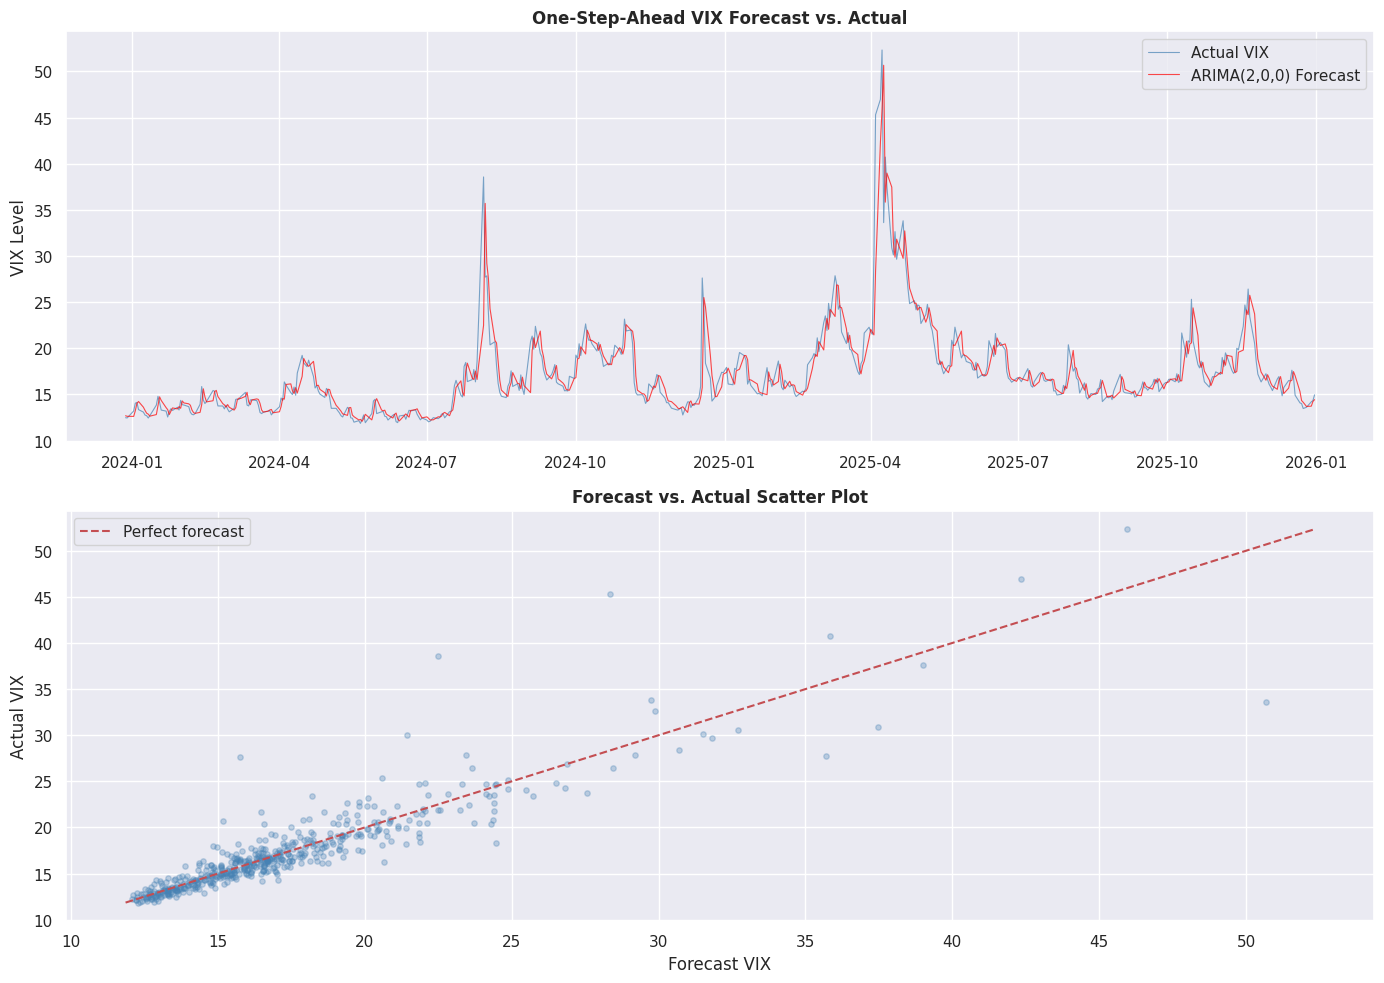

Out-of-Sample Forecast Accuracy
Mean Absolute Error (MAE):    1.09 VIX points
Root Mean Squared Error (RMSE): 2.03 VIX points
Mean Absolute % Error (MAPE): 5.55%
Median Absolute Error:        0.61 VIX points

Directional Accuracy:         49.9%
  (How often the model correctly predicted VIX up vs. down)
  (50% = coin flip, anything above 50% has some value)


In [12]:
# --- Forecast accuracy evaluation ---

# Panel 1: Forecast vs Actual over time
# Panel 2: Scatter plot of Forecast vs Actual (perfect forecast = 45-degree line)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Time series comparison
axes[0].plot(df_forecast.index, df_forecast['Actual'],
             color='steelblue', linewidth=0.8, alpha=0.7, label='Actual VIX')
axes[0].plot(df_forecast.index, df_forecast['Forecast'],
             color='red', linewidth=0.8, alpha=0.7, label='ARIMA(2,0,0) Forecast')
axes[0].set_title('One-Step-Ahead VIX Forecast vs. Actual',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('VIX Level')
axes[0].legend()

# Scatter plot: forecast vs actual
# Points on the 45-degree line = perfect forecasts
# Points above the line = model under-predicted
# Points below the line = model over-predicted
axes[1].scatter(df_forecast['Forecast'], df_forecast['Actual'],
                alpha=0.3, s=15, color='steelblue')
# Draw the 45-degree perfect forecast line
min_val = min(df_forecast['Forecast'].min(), df_forecast['Actual'].min())
max_val = max(df_forecast['Forecast'].max(), df_forecast['Actual'].max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect forecast')
axes[1].set_title('Forecast vs. Actual Scatter Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forecast VIX')
axes[1].set_ylabel('Actual VIX')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Summary error metrics ---
print("Out-of-Sample Forecast Accuracy")
print("=" * 55)
print(f"Mean Absolute Error (MAE):    {df_forecast['Abs_Error'].mean():.2f} VIX points")
print(f"Root Mean Squared Error (RMSE): {np.sqrt((df_forecast['Error']**2).mean()):.2f} VIX points")
print(f"Mean Absolute % Error (MAPE): {df_forecast['Pct_Error'].abs().mean():.2f}%")
print(f"Median Absolute Error:        {df_forecast['Abs_Error'].median():.2f} VIX points")

# --- Directional accuracy ---
# Did the model correctly predict whether VIX would go up or down?
# This matters more for trading than point accuracy
actual_direction = (df_forecast['Actual'].diff() > 0).iloc[1:]   # True = VIX went up
forecast_direction = (df_forecast['Forecast'].diff() > 0).iloc[1:] # True = forecast said up
directional_accuracy = (actual_direction == forecast_direction).mean() * 100

print(f"\nDirectional Accuracy:         {directional_accuracy:.1f}%")
print(f"  (How often the model correctly predicted VIX up vs. down)")
print(f"  (50% = coin flip, anything above 50% has some value)")

These results are honest and instructive, and they teach one of the most important lessons about forecasting in finance.

**Time series plot** (top panel): At first glance, the model looks impressive. The red forecast line tracks the blue actual VIX closely through the entire two-year period, including the spikes in August 2024 and April 2025. But look carefully: the red line is always slightly behind. It follows VIX rather than anticipating it. This is the nature of an AR model: tomorrow's forecast is essentially a weighted average of the last two days plus the long-run mean. When VIX spikes from 15 to 38 overnight, the model forecast for that day was probably around 15.5. The next day it catches up, but it is always one step behind the action.

**Scatter plot** (bottom panel): At low VIX levels (12-18), the points cluster tightly around the red perfect-forecast line. The model works well in calm markets because VIX moves slowly and the autoregressive structure is reliable. As VIX rises, the scatter increases dramatically. The points above the red line (model under-predicted) are particularly notable: actual VIX reaching 45-52 when the model forecast 25-35. The model systematically under-forecasts spikes because a linear AR model cannot anticipate a jump from 20 to 40. It can only forecast a gradual drift toward 40 after VIX has already started moving.

**Error metrics**: An MAE of 1.09 VIX points sounds good, and for most trading days it is. The median error is only 0.61 points, meaning on a typical calm day the model is off by less than a point. But the RMSE (2.03) is nearly double the MAE, which tells us the error distribution has fat tails: the rare large errors (during spikes) are much bigger than the typical error. The MAPE of 5.55% is reasonable but masks the asymmetry between calm and crisis periods.

**Directional accuracy: 49.9%**. This is the most revealing number. The model is literally no better than a coin flip at predicting whether VIX will go up or down tomorrow. Despite having significant AR coefficients, despite capturing the autocorrelation structure, despite an apparently good visual fit, the model has zero directional forecasting ability out-of-sample.

How is this possible? Because the ARIMA model's strength is level estimation, not direction prediction. It knows that if VIX is 25 today, it will probably be near 25 tomorrow. That makes the point forecast accurate (low MAE). But whether it will be 25.5 or 24.5, that is driven by the unpredictable noise term (the residuals we examined in Section 3.3), which has a standard deviation of 1.83 VIX points. The day-to-day directional move is dominated by this noise, and no amount of autoregressive modeling can predict it.

**Practical guidance:** This is a crucial result that applies far beyond ARIMA and VIX. Many models that appear to forecast well (tight tracking, low error metrics) have no directional accuracy. If your trading strategy depends on predicting direction (go long if VIX will rise, go short if it will fall), ARIMA will not help. If your strategy depends on estimating the current level or regime (is VIX elevated or calm?), ARIMA provides genuine value. Our VIXY strategy is in the second category: it compares the current volatility regime to a moving average, not predicting tomorrow's direction. This is another reason why simple moving averages work well for our use case. They estimate the regime, which is the question that actually matters.

## Section 4: SARIMAX — Adding Exogenous Variables

ARIMA uses only a series' own history to forecast. SARIMAX extends this by allowing exogenous variables: external inputs that might improve the forecast. The "S" adds seasonal components, and the "X" adds exogenous regressors.

The question we want to answer is straightforward: can we improve our VIX forecast by including SPY returns as an external input? There is a strong economic rationale for this. VIX measures implied volatility of the S&P 500, and sharp SPY declines tend to coincide with VIX spikes. If yesterday's SPY return helps predict today's VIX beyond what yesterday's VIX alone tells us, the exogenous variable adds genuine value.

We skip the seasonal component ("S") here. In Section 4 of Notebook 6.1, our seasonal decomposition showed that annual seasonality in VIX is weak and noisy. Adding a seasonal component would increase model complexity without a clear benefit.

### 4.1 Fitting SARIMAX with SPY Returns

We fit an ARIMAX(2,0,0) model — same AR structure as before, but now with yesterday's SPY return included as an exogenous variable. We compare its AIC against the pure ARIMA(2,0,0) to see if the extra input is worth the added complexity.

In [13]:
# --- Fit ARIMAX(2,0,0) with SPY returns as exogenous variable ---
# We use lagged SPY returns (yesterday's return) to avoid lookahead bias.
# If we used today's SPY return to predict today's VIX, we would be
# using information that arrives simultaneously, not predictively.

# Create aligned dataset: VIX levels with lagged SPY return
df_sarimax = pd.DataFrame({
    'VIX': df_prices['^VIX'],
    'SPY_Return_Lag1': df_returns['SPY'].shift(1)  # Yesterday's SPY return
}).dropna()

# Separate the target (VIX) and exogenous variable (lagged SPY return)
vix_sarimax = df_sarimax['VIX']
exog_sarimax = df_sarimax[['SPY_Return_Lag1']]

# Fit the model
# order=(2,0,0): same AR structure as our best ARIMA model
# exog=exog_sarimax: adds yesterday's SPY return as an external predictor
warnings.filterwarnings('ignore')
model_sarimax = SARIMAX(vix_sarimax, order=(2, 0, 0), exog=exog_sarimax).fit()
warnings.filterwarnings('default')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Compare with pure ARIMA(2,0,0)
print("Model Comparison: ARIMA vs. ARIMAX")
print("=" * 60)
print(f"\n{'Model':<25} {'AIC':>10} {'BIC':>10}")
print("-" * 60)
print(f"{'ARIMA(2,0,0)':<25} {model_ar2.aic:>10.2f} {model_ar2.bic:>10.2f}")
print(f"{'ARIMAX(2,0,0) + SPY':<25} {model_sarimax.aic:>10.2f} {model_sarimax.bic:>10.2f}")

print("\n\nARIMAX Coefficient Summary:")
print("=" * 60)
print(model_sarimax.summary().tables[1])

Model Comparison: ARIMA vs. ARIMAX

Model                            AIC        BIC
------------------------------------------------------------
ARIMA(2,0,0)                15249.46   15274.40
ARIMAX(2,0,0) + SPY         15290.28   15315.22


ARIMAX Coefficient Summary:
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
SPY_Return_Lag1     1.1671      1.260      0.926      0.354      -1.303       3.638
ar.L1               0.8390      0.009     90.168      0.000       0.821       0.857
ar.L2               0.1571      0.010     16.118      0.000       0.138       0.176
sigma2              3.3723      0.022    153.878      0.000       3.329       3.415


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


The results are unambiguous: adding yesterday's SPY return does not improve the model.

The AIC actually increases from 15,249 to 15,290, meaning the model got worse, not better. Remember, lower AIC is better, and the penalty for adding an extra parameter is only about 2 AIC points. An increase of 41 points means the exogenous variable is not just unhelpful — it is actively degrading model quality by adding noise.

The coefficient tells the same story. The SPY_Return_Lag1 coefficient is 1.17 with a p-value of 0.354, well above our 0.05 significance threshold. We cannot reject the null hypothesis that this coefficient is zero. In plain language: yesterday's SPY return has no statistically significant ability to predict today's VIX level, once you already know yesterday's and the day before's VIX.

This might seem counterintuitive. We know that SPY drops and VIX spikes happen at the same time. The key word is "at the same time." The relationship between SPY and VIX is contemporaneous, not predictive. Yesterday's SPY return does not tell you anything about today's VIX that yesterday's VIX does not already capture. By the time you observe the SPY decline, VIX has already spiked. The information is already priced in.

The AR coefficients (ar.L1 = 0.839, ar.L2 = 0.157) are nearly identical to the pure ARIMA model (0.819 and 0.150), confirming that the SPY variable is not changing how the model uses VIX's own history. The sigma2 (error variance) is also essentially unchanged at 3.37 versus 3.33.

**Practical guidance:** This result is common in quantitative finance and worth internalizing. Many relationships that look strong in charts (SPY drops, VIX spikes) are contemporaneous, not lagged. For an exogenous variable to improve a forecast, it needs to contain information about the future that is not already in the target series' own history. In practice, variables that genuinely improve VIX forecasts tend to be forward-looking measures like options order flow, credit spreads, or measures of institutional hedging demand — data that is expensive, difficult to obtain, and often proprietary. Free, easily available data like lagged SPY returns has already been arbitraged into the VIX level by the time you observe it.

This is why our VIXY strategy does not try to forecast VIX. Instead, it compares the current VIX regime to realized volatility — a relationship that does not require prediction, only measurement.

## Section 5: Key Takeaways and Connection to Advanced Techniques

This notebook covered the two most accessible and widely used signal processing tools in quantitative finance. Before we move to the advanced techniques in Notebook 6.3, let us consolidate what we learned.

In [14]:
# --- Summary comparison of all techniques explored ---
# This table gives readers a single reference for the tradeoffs
# we demonstrated throughout this notebook.

summary = {
    'Technique': [
        '20-day SMA',
        '90-day SMA (our strategy)',
        '200-day SMA',
        '90-day EMA',
        'ARIMA(2,0,0)',
        'ARIMAX(2,0,0) + SPY'
    ],
    'Purpose': [
        'Short-term smoothing',
        'Medium-term regime detection',
        'Long-term trend identification',
        'Faster regime detection',
        'Level forecasting',
        'Level forecasting with external input'
    ],
    'Estimated Lag': [
        '10 days',
        '44 days',
        '60+ days',
        '20 days',
        '1 day (forecast)',
        '1 day (forecast)'
    ],
    'Directional Accuracy': [
        'N/A (smoother, not forecaster)',
        'N/A (smoother, not forecaster)',
        'N/A (smoother, not forecaster)',
        'N/A (smoother, not forecaster)',
        '49.9% (coin flip)',
        'Not tested (worse model)'
    ],
    'Verdict': [
        'Too noisy for regime signals',
        'Good balance for tail hedge',
        'Too much lag for tactical use',
        'Less lag, worth testing in 6.4',
        'Good level estimates, no direction',
        'SPY adds no predictive value'
    ]
}

df_summary = pd.DataFrame(summary).set_index('Technique')

print("Summary: Moving Averages and ARIMA on VIX")
print("=" * 95)
print(df_summary.to_string())

Summary: Moving Averages and ARIMA on VIX
                                                         Purpose     Estimated Lag            Directional Accuracy                             Verdict
Technique                                                                                                                                             
20-day SMA                                  Short-term smoothing           10 days  N/A (smoother, not forecaster)        Too noisy for regime signals
90-day SMA (our strategy)           Medium-term regime detection           44 days  N/A (smoother, not forecaster)         Good balance for tail hedge
200-day SMA                       Long-term trend identification          60+ days  N/A (smoother, not forecaster)       Too much lag for tactical use
90-day EMA                               Faster regime detection           20 days  N/A (smoother, not forecaster)      Less lag, worth testing in 6.4
ARIMA(2,0,0)                                   Level

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


This table captures the core lessons from Notebook 6.2 as they apply to our VIX case study. But the tools we covered here have applications well beyond what we demonstrated, and it is important to put them in proper context.

**Moving averages** are arguably the most widely used tool in all of quantitative finance. We used them here as noise filters on VIX, but their applications are far broader:

- **Trend identification and trading signals**: Moving average crossover strategies (when a short MA crosses above a long MA, buy; when it crosses below, sell) are among the most popular systematic strategies in the world. We will build and test several of these in Chapter 12.
- **Regime detection**: Our VIXY strategy uses the 90-day SMA to define a volatility regime. The same logic applies to any mean-reverting series: credit spreads, interest rate differentials, commodity basis.
- **Smoothing inputs for other models**: Moving averages are frequently used to create stable features for machine learning models (Chapters 13-14). A 20-day average of trading volume, for example, is a more reliable feature than raw daily volume.
- **Risk management**: Rolling volatility calculations (which are moving averages of squared returns) are the foundation of position sizing, VaR models, and portfolio risk monitoring across the industry.

For our case study, the 90-day SMA remains a solid choice for regime detection, and the 90-day EMA offers a compelling alternative with half the lag. We will test whether that translates to better strategy performance in Notebook 6.4.

**ARIMA models** produced accurate level estimates for VIX but could not predict direction. This is not a failure of our specific model — it reflects a fundamental characteristic of autoregressive models applied to noisy financial data. However, the result should not be taken to mean ARIMA is useless. ARIMA models have legitimate applications in finance:

- **Volatility forecasting**: ARIMA on realized volatility or VIX is commonly used in options pricing and risk management, where knowing the expected level of future volatility matters more than knowing its direction.
- **Interest rates and fixed income**: Bond yields, credit spreads, and term structure factors have strong autoregressive properties. ARIMA and its extensions (particularly GARCH for volatility modeling) are standard tools in fixed income desks.
- **Economic data**: GDP growth, inflation, unemployment claims — macroeconomic series are often well-suited to ARIMA because they are reported at regular intervals and have genuine seasonal structure (making SARIMAX particularly useful).
- **Baseline forecasts**: Even when ARIMA alone is not sufficient, it often serves as a useful benchmark. If a complex machine learning model cannot beat an ARIMA forecast, the ML model is probably overfitting.

**Adding exogenous variables did not help in our case** because the SPY-VIX relationship is contemporaneous, not predictive. But SARIMAX is a valuable tool when you have genuinely leading indicators: for example, using initial jobless claims to forecast consumer spending, or using options order flow to forecast volatility.

**Can ARIMA models be used directly in algorithmic trading strategies?** This is a question readers will naturally ask, and the honest answer is: they can, but they rarely produce stable, reliable trading systems. The core problem is parameter instability. The AR coefficients and model structure that fit well on one period of data may shift significantly in the next period, especially across different market regimes. A model calibrated during a calm, low-volatility environment will behave very differently when a crisis hits. You can recalibrate frequently (as we did in our rolling forecast), but then you are constantly trading on a slightly different model, which makes it difficult to understand what your strategy is actually doing and why. In practice, strategies built directly on ARIMA forecasts tend to degrade over time and require constant maintenance and re-tuning. This does not mean the underlying concepts are worthless — understanding autoregressive structure, mean-reversion, and autocorrelation is essential knowledge. But when it comes to building a trading system you can trust, simpler rules-based approaches (like moving average crossovers in Chapter 12), regime-detection frameworks (like our VIXY strategy), and machine learning models with proper validation (Chapters 13-14) tend to produce more stable and interpretable results. ARIMA is best thought of as an analytical tool for understanding your data and as a forecasting benchmark, rather than as the engine of a production trading strategy.

**Connection to Notebook 6.3:** The advanced techniques (Kalman filters, Fourier transforms, wavelets, fractional differencing) offer different approaches to the same fundamental challenge. Kalman filters are adaptive smoothers that may respond to regime changes faster than a fixed-window MA. Fourier and wavelets decompose the signal into frequency components rather than smoothing it in the time domain. Fractional differencing addresses a different problem entirely: preserving memory while achieving stationarity. Whether any of these improve on the simple tools we explored here is an empirical question we will answer in Notebook 6.4.

The bar has been set: 90-day SMA on VIX, simple, interpretable, and effective for regime detection. The advanced techniques need to clear that bar to justify their added complexity.

